# Model Comparison: YOLO26m v1 vs MobileNet

This notebook compares the performance of two face mask detection models:
- **YOLO26m v1**: Object detection model (face_mask_detection_yolo26m_v1_best.pt)
- **MobileNet**: Classification model trained on ground truth boxes (face_mask_mobilenet_best.h5)

## How to Calculate Model Parameters

**Formula for Dense/Fully Connected Layers:**
```
Parameters = (input_size × output_size) + output_size
           = (input_size × output_size) + bias_terms
```

**Example: Dense(256) after 1280 inputs:**
```
Parameters = (1280 × 256) + 256 = 327,936
```

**Formula for Convolutional Layers:**
```
Parameters = (kernel_height × kernel_width × input_channels × output_channels) + output_channels
```

**Example: Conv2D(3×3, input=32, output=64):**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 18,496
```

**Formula for Batch Normalization:**
```
Parameters = 2 × num_features  (scale + shift parameters)
           + 2 × num_features  (running mean + variance, not trainable)
```

**Example: BatchNorm(256 features):**
```
Parameters = 2 × 256 = 512 (trainable)
```

**Layers with NO Parameters:**
- Activation layers (ReLU, Sigmoid, etc.)
- Dropout layers
- GlobalAveragePooling layers
- Max/Average Pooling layers

In [91]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [92]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
YOLO26M_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolo26m_v1_best.pt'
MOBILENET_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_mobilenet_best.h5'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

print(f"YOLO26m model exists: {YOLO26M_MODEL_PATH.exists()}")
print(f"MobileNet model exists: {MOBILENET_MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

YOLO26m model exists: True
MobileNet model exists: True
Test images directory exists: True
Test labels directory exists: True


In [93]:
# Load models
print("Loading YOLO26m model...")
yolo_model = YOLO(str(YOLO26M_MODEL_PATH))

print("Loading MobileNet model (trained on ground truth boxes)...")
mobilenet_model = keras.models.load_model(str(MOBILENET_MODEL_PATH), compile=False)

print("All models loaded successfully!")

Loading YOLO26m model...
Loading MobileNet model (trained on ground truth boxes)...
All models loaded successfully!


In [94]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

print("Sample test image paths:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 578 test images
Sample test image paths:
  0020.jpg
  0049.jpg
  0054.jpg


## YOLO26m v1 Model Evaluation

Detection performance of the YOLO26m v1 model.

In [105]:
# YOLO26m Predictions - Using IoU-based matching (same as visualization_yolo26_detect_face)
print("Running YOLO26m predictions on test set...")
print("(Using IoU-based matching with ground truth)\n")

yolo_y_true = []
yolo_y_pred = []
yolo_confidences = []
yolo_ious = []
yolo_false_positives = 0

def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox to pixel coordinates"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

for img_path in tqdm(test_images):
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Run prediction
    results = yolo_model(str(img_path), verbose=False)
    
    # Extract predictions
    pred_boxes = []
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, xyxy)
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                pred_boxes.append((x1, y1, x2, y2, pred_class, confidence))
    
    # Match predictions with ground truth using IoU
    matched_gt = set()
    for pred_box in pred_boxes:
        pred_x1, pred_y1, pred_x2, pred_y2, pred_class, confidence = pred_box
        
        best_iou = 0
        best_gt_idx = -1
        best_gt_class = None
        
        # Find best matching ground truth box
        for gt_idx, (gt_class, center_x, center_y, bbox_w, bbox_h) in enumerate(gt_labels):
            if gt_idx in matched_gt:
                continue
            
            gt_x1, gt_y1, gt_x2, gt_y2 = convert_yolo_to_pixel_coords(
                (center_x, center_y, bbox_w, bbox_h), img_w, img_h
            )
            iou = calculate_iou((pred_x1, pred_y1, pred_x2, pred_y2), (gt_x1, gt_y1, gt_x2, gt_y2))
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
                best_gt_class = gt_class
        
        # Only evaluate matched detections for classification metrics
        if best_gt_class is not None and best_iou > 0.0:
            matched_gt.add(best_gt_idx)
            yolo_y_true.append(best_gt_class)
            yolo_y_pred.append(pred_class)
            yolo_confidences.append(confidence)
            yolo_ious.append(best_iou)
        else:
            yolo_false_positives += 1

print(f"\n✓ YOLO26m evaluation complete!")
print(f"YOLO26m - Matched detections: {len(yolo_y_pred)}")
print(f"YOLO26m - False positives (no GT match): {yolo_false_positives}")

Running YOLO26m predictions on test set...
(Using IoU-based matching with ground truth)



100%|██████████| 578/578 [00:11<00:00, 50.78it/s]


✓ YOLO26m evaluation complete!
YOLO26m - Matched detections: 1209
YOLO26m - False positives (no GT match): 212


In [106]:
# Calculate YOLO26m metrics (on matched detections only)
yolo_accuracy = accuracy_score(yolo_y_true, yolo_y_pred)
yolo_precision = precision_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_recall = recall_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_f1 = f1_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)

# Per-class metrics
yolo_precision_per_class = precision_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_recall_per_class = recall_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_f1_per_class = f1_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)

print("YOLO26m Model Metrics (on matched detections):")
print(f"  Accuracy:  {yolo_accuracy:.4f}")
print(f"  Precision: {yolo_precision:.4f}")
print(f"  Recall:    {yolo_recall:.4f}")
print(f"  F1-Score:  {yolo_f1:.4f}")
print(f"  Avg Confidence: {np.mean(yolo_confidences):.4f}")
print(f"\n  Detection Statistics:")
print(f"    Matched detections: {len(yolo_y_pred)}")
print(f"    False positives: {yolo_false_positives}")
print(f"\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(yolo_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {yolo_precision_per_class[i]:.4f}")
        print(f"    Recall:    {yolo_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {yolo_f1_per_class[i]:.4f}")

YOLO26m Model Metrics (on matched detections):
  Accuracy:  0.9537
  Precision: 0.9472
  Recall:    0.9537
  F1-Score:  0.9495
  Avg Confidence: 0.7132

  Detection Statistics:
    Matched detections: 1209
    False positives: 212

Per-class metrics:
  With Mask:
    Precision: 0.9677
    Recall:    0.9826
    F1-Score:  0.9751
  Without Mask:
    Precision: 0.9293
    Recall:    0.9340
    F1-Score:  0.9316
  Mask Weared Incorrect:
    Precision: 0.4737
    Recall:    0.2571
    F1-Score:  0.3333


## MobileNet Model Evaluation (Real-World Usage)

**Real-world pipeline:** YOLO26m detects faces → MobileNet classifies them (evaluates ALL detections)

This approach:
1. YOLO26m detects faces in images (all detections)
2. MobileNet classifies each detected face region
3. Compare with ground truth to get accuracy
4. **Note:** Includes ALL detections (even poor quality ones) - realistic performance metric

In [107]:
# MobileNet Predictions using YOLO26m detections (REAL-WORLD USE CASE)
print("Running MobileNet predictions on YOLO26m detected faces...")
print("(Real-world evaluation: includes false positives and false negatives)\n")

mobilenet_y_true = []
mobilenet_y_pred = []
mobilenet_confidences = []
total_yolo_detections = 0
total_gt_faces = 0
total_matched = 0
mobilenet_false_positives = 0

# Image size for MobileNet
IMG_SIZE = 192  # MobileNet was trained with 192x192 input

def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox (normalized center_x, center_y, width, height) to pixel coordinates (x1, y1, x2, y2)"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    
    # Convert from normalized to pixel coordinates
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    # Calculate top-left and bottom-right corners
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    # Clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in format (x1, y1, x2, y2)"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    total_gt_faces += len(gt_labels)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Run YOLO26m detection
    results = yolo_model(str(img_path), verbose=False)
    
    # Track matched GT boxes
    matched_gt = set()
    
    # Process each YOLO detection
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                total_yolo_detections += 1
                # Get YOLO detection bbox in xyxy format
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, xyxy)
                
                # Find matching ground truth box using IoU
                max_iou = 0
                matched_gt_class = None
                matched_gt_idx = -1
                for gt_idx, (gt_class, center_x, center_y, bbox_w, bbox_h) in enumerate(gt_labels):
                    if gt_idx in matched_gt:
                        continue
                    gt_x1, gt_y1, gt_x2, gt_y2 = convert_yolo_to_pixel_coords(
                        (center_x, center_y, bbox_w, bbox_h), img_w, img_h
                    )
                    iou = calculate_iou((x1, y1, x2, y2), (gt_x1, gt_y1, gt_x2, gt_y2))
                    if iou > max_iou:
                        max_iou = iou
                        matched_gt_class = gt_class
                        matched_gt_idx = gt_idx
                
                # Crop detected face region
                face = img[y1:y2, x1:x2]
                if face.size == 0:
                    continue
                
                # Preprocess for MobileNet
                face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
                face_normalized = face_rgb / 255.0
                face_batch = np.expand_dims(face_normalized, axis=0)
                
                # Predict
                pred = mobilenet_model.predict(face_batch, verbose=0)
                pred_class = np.argmax(pred[0])
                confidence = np.max(pred[0])
                
                # Only evaluate matched detections for classification metrics
                if matched_gt_class is not None and max_iou > 0.0:
                    matched_gt.add(matched_gt_idx)
                    total_matched += 1
                    mobilenet_y_true.append(matched_gt_class)
                    mobilenet_y_pred.append(pred_class)
                    mobilenet_confidences.append(confidence)
                # FALSE POSITIVE: detection with no ground truth match
                else:
                    mobilenet_false_positives += 1

print(f"\n=== REAL-WORLD PERFORMANCE METRICS ===")
print(f"\nMobileNet - YOLO26m Detection Statistics:")
print(f"  Total ground truth faces: {total_gt_faces}")
print(f"  Total YOLO detections: {total_yolo_detections}")
print(f"  True positives (matched): {total_matched}")
print(f"  False positives (no GT match): {total_yolo_detections - total_matched}")
print(f"  False negatives (missed GT): {total_gt_faces - total_matched}")
print(f"\n  Detection Rate (Recall): {total_matched/total_gt_faces*100:.2f}% (found {total_matched}/{total_gt_faces} faces)")
if total_yolo_detections > 0:
    print(f"  False Positive Rate: {(total_yolo_detections - total_matched)/total_yolo_detections*100:.2f}%")
print(f"\nMobileNet - Classification on {len(mobilenet_y_pred)} matched detections")

Running MobileNet predictions on YOLO26m detected faces...
(Real-world evaluation: includes false positives and false negatives)



100%|██████████| 578/578 [00:57<00:00, 10.08it/s]


=== REAL-WORLD PERFORMANCE METRICS ===

MobileNet - YOLO26m Detection Statistics:
  Total ground truth faces: 1393
  Total YOLO detections: 1421
  True positives (matched): 1209
  False positives (no GT match): 212
  False negatives (missed GT): 184

  Detection Rate (Recall): 86.79% (found 1209/1393 faces)
  False Positive Rate: 14.92%

MobileNet - Classification on 1209 matched detections


In [108]:
# Calculate MobileNet metrics (on matched detections only)
mobilenet_accuracy = accuracy_score(mobilenet_y_true, mobilenet_y_pred)
mobilenet_precision = precision_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_recall = recall_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_f1 = f1_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)

# Per-class metrics
mobilenet_precision_per_class = precision_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_recall_per_class = recall_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_f1_per_class = f1_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)

print("MobileNet Model Metrics (on matched detections):")
print(f"  Accuracy:  {mobilenet_accuracy:.4f}")
print(f"  Precision: {mobilenet_precision:.4f}")
print(f"  Recall:    {mobilenet_recall:.4f}")
print(f"  F1-Score:  {mobilenet_f1:.4f}")
print(f"  Avg Confidence: {np.mean(mobilenet_confidences):.4f}")
print(f"\n  Detection Statistics:")
print(f"    Matched detections: {len(mobilenet_y_pred)}")
print(f"    False positives: {mobilenet_false_positives}")
print(f"\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(mobilenet_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {mobilenet_precision_per_class[i]:.4f}")
        print(f"    Recall:    {mobilenet_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {mobilenet_f1_per_class[i]:.4f}")

MobileNet Model Metrics (on matched detections):
  Accuracy:  0.9231
  Precision: 0.9179
  Recall:    0.9231
  F1-Score:  0.9195
  Avg Confidence: 1.4084

  Detection Statistics:
    Matched detections: 1209
    False positives: 212

Per-class metrics:
  With Mask:
    Precision: 0.9532
    Recall:    0.9580
    F1-Score:  0.9556
  Without Mask:
    Precision: 0.8221
    Recall:    0.8680
    F1-Score:  0.8444
  Mask Weared Incorrect:
    Precision: 0.4737
    Recall:    0.2571
    F1-Score:  0.3333


## Model Comparison: YOLO26m v1 vs MobileNet

**Fair Classification Comparison:**
- Both models share the **same YOLO26m detection backbone** — only the classifier differs
- All metrics are computed on **matched detections only** (IoU > 0 with ground truth)
- Detection statistics (false positives, missed faces) are reported separately
- This isolates classification performance for a direct, fair comparison

In [109]:
# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Confidence'],
    'YOLO26m v1': [
        f'{yolo_accuracy:.4f}',
        f'{yolo_precision:.4f}',
        f'{yolo_recall:.4f}',
        f'{yolo_f1:.4f}',
        f'{np.mean(yolo_confidences):.4f}'
    ],
    'MobileNet': [
        f'{mobilenet_accuracy:.4f}',
        f'{mobilenet_precision:.4f}',
        f'{mobilenet_recall:.4f}',
        f'{mobilenet_f1:.4f}',
        f'{np.mean(mobilenet_confidences):.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("OVERALL MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


OVERALL MODEL COMPARISON
        Metric YOLO26m v1 MobileNet
      Accuracy     0.9537    0.9231
     Precision     0.9472    0.9179
        Recall     0.9537    0.9231
      F1-Score     0.9495    0.9195
Avg Confidence     0.7132    1.4084


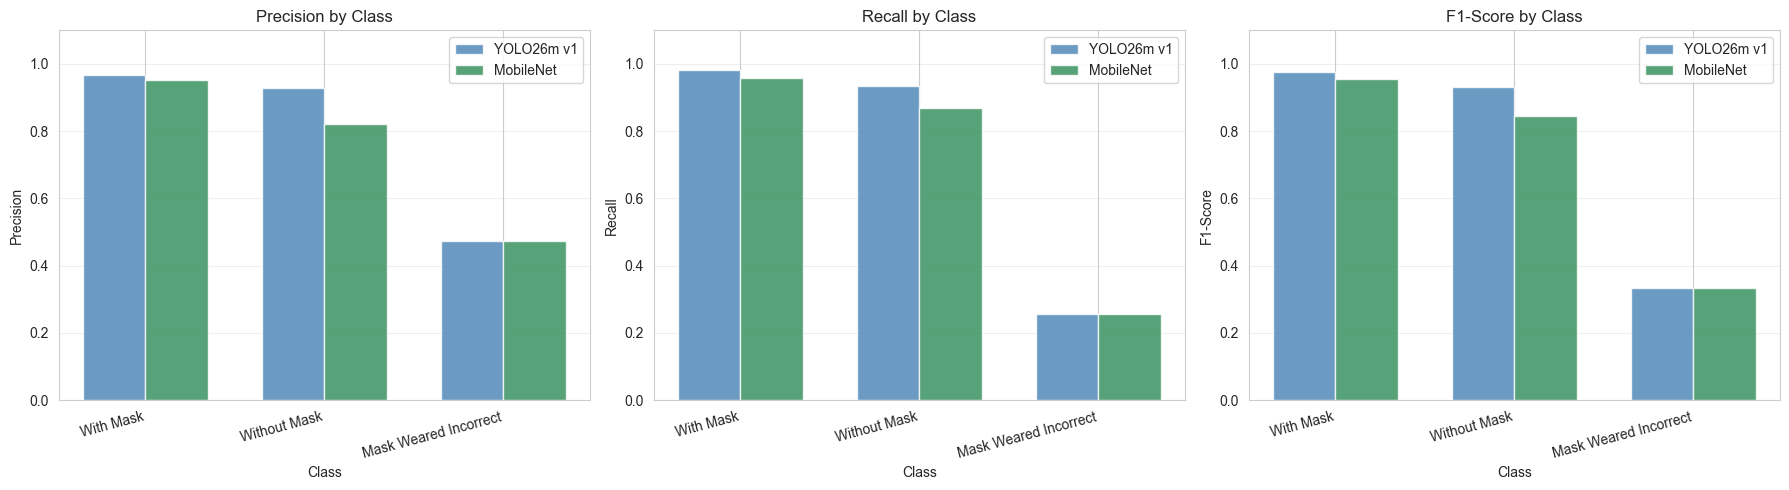

In [110]:
# Per-class comparison - 2 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
yolo_metrics = [yolo_precision_per_class, yolo_recall_per_class, yolo_f1_per_class]
mobilenet_metrics = [mobilenet_precision_per_class, mobilenet_recall_per_class, mobilenet_f1_per_class]

for idx, (metric_name, yolo_vals, mobilenet_vals) in enumerate(zip(metrics, yolo_metrics, mobilenet_metrics)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.35
    
    # Ensure all classes are represented
    yolo_plot = np.zeros(len(CLASS_NAMES))
    mobilenet_plot = np.zeros(len(CLASS_NAMES))
    
    for i in range(len(CLASS_NAMES)):
        if i < len(yolo_vals):
            yolo_plot[i] = yolo_vals[i]
        if i < len(mobilenet_vals):
            mobilenet_plot[i] = mobilenet_vals[i]
    
    ax.bar(x - width/2, yolo_plot, width, label='YOLO26m v1', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, mobilenet_plot, width, label='MobileNet', alpha=0.8, color='seagreen')
    
    ax.set_xlabel('Class')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

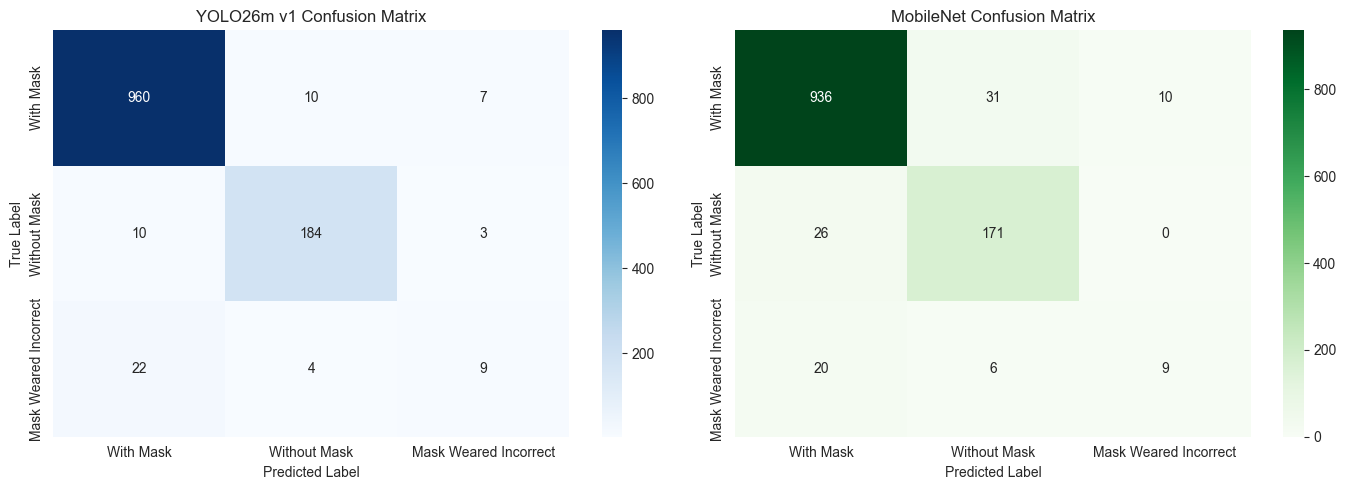

In [111]:
# Confusion Matrices for 2 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YOLO26m Confusion Matrix
yolo_cm = confusion_matrix(yolo_y_true, yolo_y_pred, labels=[0, 1, 2])
sns.heatmap(yolo_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('YOLO26m v1 Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# MobileNet Confusion Matrix
mobilenet_cm = confusion_matrix(mobilenet_y_true, mobilenet_y_pred, labels=[0, 1, 2])
sns.heatmap(mobilenet_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('MobileNet Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

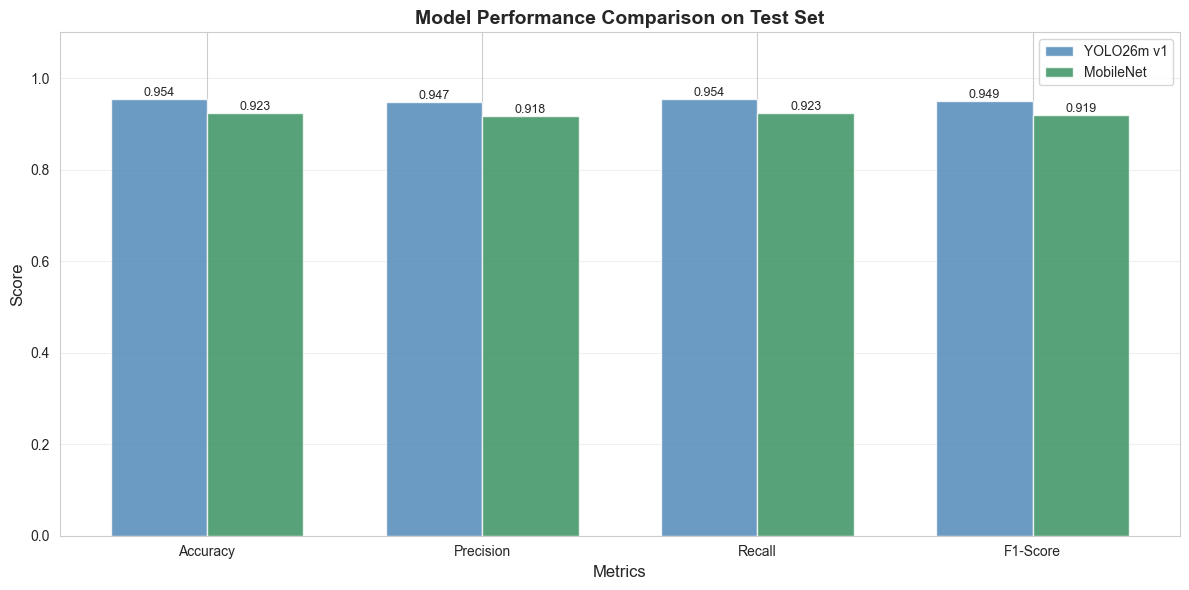

In [112]:
# Overall metrics comparison bar chart - 2 models
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
yolo_values = [yolo_accuracy, yolo_precision, yolo_recall, yolo_f1]
mobilenet_values = [mobilenet_accuracy, mobilenet_precision, mobilenet_recall, mobilenet_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, yolo_values, width, label='YOLO26m v1', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, mobilenet_values, width, label='MobileNet', alpha=0.8, color='seagreen')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [113]:
# Detailed Classification Reports
print("="*80)
print("YOLO26M V1 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(yolo_y_true, yolo_y_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))

print("\n" + "="*80)
print("MOBILENET CLASSIFICATION REPORT")
print("="*80)
print(classification_report(mobilenet_y_true, mobilenet_y_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))

YOLO26M V1 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.97      0.98      0.98       977
         Without Mask       0.93      0.93      0.93       197
Mask Weared Incorrect       0.47      0.26      0.33        35

             accuracy                           0.95      1209
            macro avg       0.79      0.72      0.75      1209
         weighted avg       0.95      0.95      0.95      1209


MOBILENET CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.95      0.96      0.96       977
         Without Mask       0.82      0.87      0.84       197
Mask Weared Incorrect       0.47      0.26      0.33        35

             accuracy                           0.92      1209
            macro avg       0.75      0.69      0.71      1209
         weighted avg       0.92      0.92      0.92      1209

